In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.tree import plot_tree
from sklearn.tree import export_text

In [2]:
wine = load_wine(as_frame=True)

df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (178, 13)
Размер y: (178,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (142, 13)
Тестовая выборка: (36, 13)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
log_reg = LogisticRegression(max_iter=5000)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log, average="weighted")

print("Accuracy Logistic Regression:", accuracy_log)
print("F1-score Logistic Regression:", f1_log)

Accuracy Logistic Regression: 0.9722222222222222
F1-score Logistic Regression: 0.9719701552732407


In [9]:
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average="weighted")

print("Accuracy SVM:", accuracy_svm)
print("F1-score SVM:", f1_svm)

Accuracy SVM: 0.9722222222222222
F1-score SVM: 0.9719701552732407


In [10]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("Accuracy Decision Tree:", accuracy_tree)
print("F1-score Decision Tree:", f1_tree)

Accuracy Decision Tree: 0.9444444444444444
F1-score Decision Tree: 0.9449614374099499


In [20]:
results = pd.DataFrame({
    "Модель": [
        "Logistic Regression",
        "SVM",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_svm,
        accuracy_tree
    ],
    "F1-score": [
        f1_log,
        f1_svm,
        f1_tree
    ]
})

results

print(results)

                Модель  Accuracy  F1-score
0  Logistic Regression  0.972222  0.971970
1                  SVM  0.972222  0.971970
2        Decision Tree  0.944444  0.944961


In [12]:
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nОтчет классификации:")
print(classification_report(y_test, y_pred_tree))

Матрица ошибок:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]

Отчет классификации:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [13]:
feature_importance = pd.DataFrame({
    "Признак": X.columns,
    "Важность": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Важность",
    ascending=False
)

feature_importance

,Признак,Важность
6,flavanoids,0.408073
9,color_intensity,0.400189
12,proline,0.110985
11,od280/od315_of_diluted_wines,0.020986
3,alcalinity_of_ash,0.020865
2,ash,0.020163
1,malic_acid,0.018738
4,magnesium,0.000000
0,alcohol,0.000000
8,proanthocyanins,0.000000


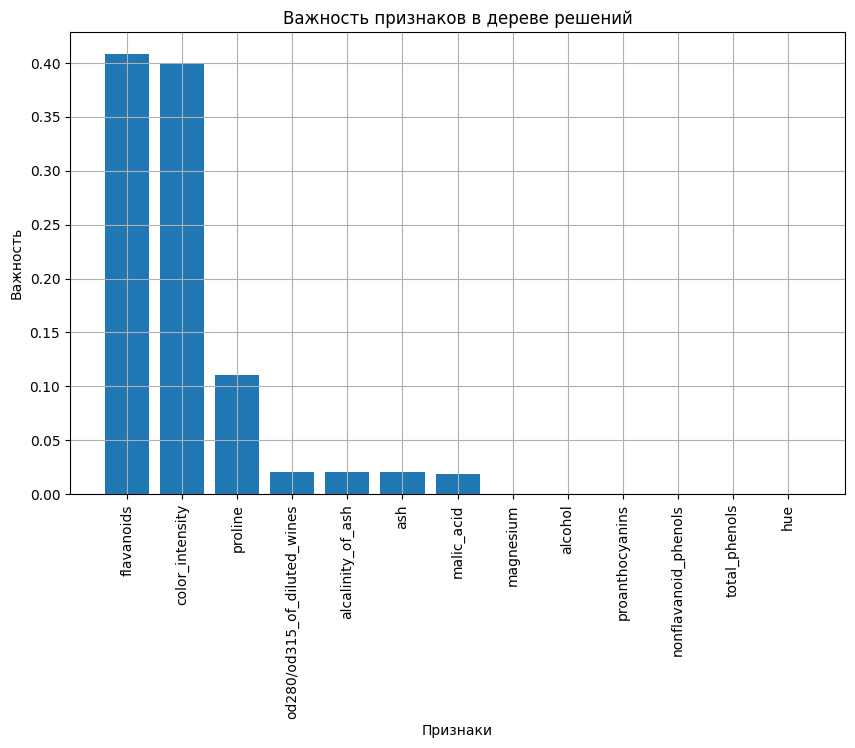

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Признак"],
    feature_importance["Важность"]
)

plt.xticks(rotation=90)

plt.title("Важность признаков в дереве решений")

plt.xlabel("Признаки")
plt.ylabel("Важность")

plt.grid()

plt.show()

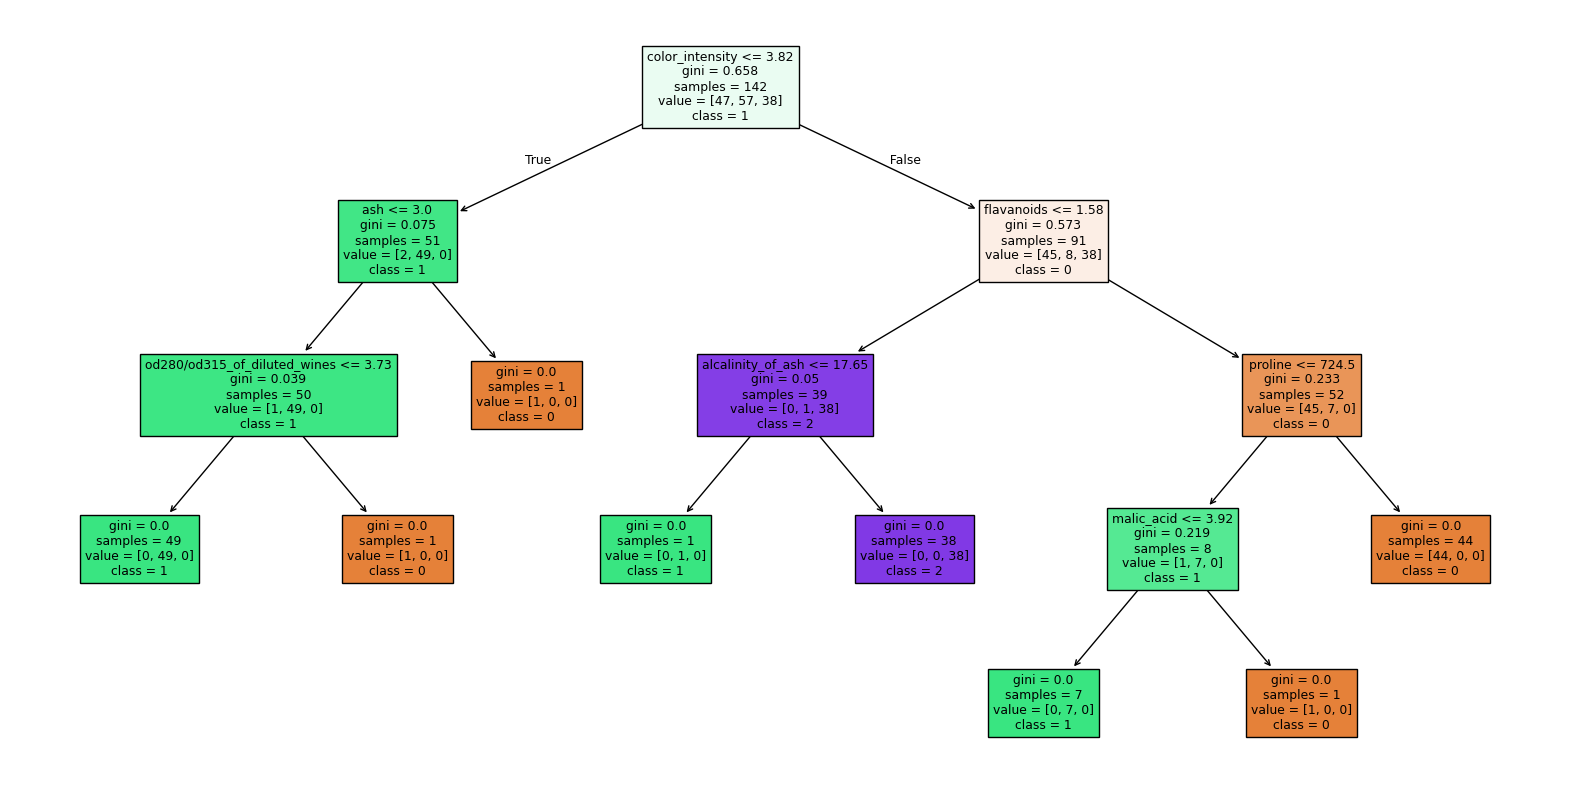

In [15]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["0", "1", "2"],
    filled=True
)

plt.show()

In [16]:
tree_rules = export_text(
    tree_model,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- color_intensity <= 3.82
|   |--- ash <= 3.00
|   |   |--- od280/od315_of_diluted_wines <= 3.73
|   |   |   |--- class: 1
|   |   |--- od280/od315_of_diluted_wines >  3.73
|   |   |   |--- class: 0
|   |--- ash >  3.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 724.50
|   |   |   |--- malic_acid <= 3.92
|   |   |   |   |--- class: 1
|   |   |   |--- malic_acid >  3.92
|   |   |   |   |--- class: 0
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



In [18]:
print("""
В данной лабораторной работе был использован датасет Wine
для решения задачи классификации.

Были обучены три модели:
- Logistic Regression;
- SVM;
- Decision Tree.

Качество моделей оценивалось с помощью метрик accuracy и F1-score.

Наилучшее качество показали модели Logistic Regression и SVM:
accuracy = 0.9722.

Модель дерева решений показала немного более низкое качество:
accuracy = 0.9444.

Также для дерева решений были рассчитаны важности признаков.
Наиболее важными признаками оказались flavanoids,
color_intensity и proline.

Дополнительно было визуализировано дерево решений
и выведены правила принятия решений в текстовом виде.

Таким образом, были изучены линейные модели,
SVM и деревья решений, а также выполнено сравнение
их качества на задаче классификации.
""")


В данной лабораторной работе был использован датасет Wine
для решения задачи классификации.

Были обучены три модели:
- Logistic Regression;
- SVM;
- Decision Tree.

Качество моделей оценивалось с помощью метрик accuracy и F1-score.

Наилучшее качество показали модели Logistic Regression и SVM:
accuracy = 0.9722.

Модель дерева решений показала немного более низкое качество:
accuracy = 0.9444.

Также для дерева решений были рассчитаны важности признаков.
Наиболее важными признаками оказались flavanoids,
color_intensity и proline.

Дополнительно было визуализировано дерево решений
и выведены правила принятия решений в текстовом виде.

Таким образом, были изучены линейные модели,
SVM и деревья решений, а также выполнено сравнение
их качества на задаче классификации.

